In [1]:
import torch, torch_geometric

device = torch.device("mps" if torch.backends.mps.is_available() else print("CPU"))

/Users/krishpatel/code/VSC/HOMO_LUMO_Prediction/gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
import time
from collections import Counter

import torch
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

from torch_geometric.datasets import QM9
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool, global_add_pool

torch.manual_seed(0)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("torch:", torch.__version__)
print("device:", device)

torch: 2.13.0
device: mps


In [3]:
torch.manual_seed(0)
a = torch.randn(3)
b = torch.randn(3)
print("a first: ", a.tolist())
print("b second:", b.tolist())

torch.manual_seed(0)
b2 = torch.randn(3)
a2 = torch.randn(3)
print("b first: ", b2.tolist())
print("a second:", a2.tolist())

a first:  [1.5409960746765137, -0.293428897857666, -2.1787893772125244]
b second: [0.5684312582015991, -1.0845223665237427, -1.3985954523086548]
b first:  [1.5409960746765137, -0.293428897857666, -2.1787893772125244]
a second: [0.5684312582015991, -1.0845223665237427, -1.3985954523086548]


In [4]:
import sys
print(sys.executable)

/Users/krishpatel/code/VSC/HOMO_LUMO_Prediction/gnn/bin/python


In [5]:
#loading the QM9 dataset (to only utilize row 4) and verifying the number of molecules and the target vector per molecule
dataset = QM9(root='data/QM9')

print(dataset)
print("molecules:", len(dataset))
print("target vector per molecule:", tuple(dataset[0].y.shape))

QM9(130831)
molecules: 130831
target vector per molecule: (1, 19)


In [6]:
#verifying that row 4 is row 3-2 (homo-lumo eV size)

TARGET = 4
ATOM_TYPES = ["H", "C", "N", "O", "F"]
BOND_TYPES = ["single", "double", "triple", "aromatic"]

y = dataset[0].y[0]
print("HOMO:", round(y[2].item(), 4), "eV")
print("LUMO:", round(y[3].item(), 4), "eV")
print("gap :", round(y[4].item(), 4), "eV")
print("LUMO - HOMO =", round((y[3] - y[2]).item(), 4), "eV")

HOMO: -10.5499 eV
LUMO: 3.1865 eV
gap : 13.7363 eV
LUMO - HOMO = 13.7363 eV


In [7]:
mol = dataset[100]
print(mol)

Data(x=[11, 11], edge_index=[2, 22], edge_attr=[22, 4], y=[1, 19], pos=[11, 3], idx=[1], name='gdb_104', z=[11])


In [8]:
#converting edges and nodes graph to atoms and chemical bond representation based on formula
symbols = [ATOM_TYPES[int(row.argmax())] for row in mol.x[:, :5]]

counts = Counter(symbols)
formula = "".join(el + str(counts[el]) for el in ["C", "H", "N", "O", "F"] if counts[el])
print("formula:", formula)
print("atoms  :", symbols)
print()

print("bonds:")
seen = set()
for e in range(mol.edge_index.size(1)):
    i = int(mol.edge_index[0, e])
    j = int(mol.edge_index[1, e])
    if (j, i) in seen:
        continue
    seen.add((i, j))
    order = BOND_TYPES[int(mol.edge_attr[e].argmax())]
    print("  " + symbols[i] + str(i) + " -- " + symbols[j] + str(j) + "   " + order)

formula: C3H6O2
atoms  : ['O', 'C', 'C', 'C', 'O', 'H', 'H', 'H', 'H', 'H', 'H']

bonds:
  O0 -- C1   single
  O0 -- H5   single
  C1 -- C2   single
  C1 -- C3   single
  C1 -- H6   single
  C2 -- C3   single
  C2 -- H7   single
  C2 -- H8   single
  C3 -- O4   single
  C3 -- H9   single
  O4 -- H10   single


In [9]:
print("gap:", round(mol.y[0][4].item(), 3), "eV")

gap: 8.193 eV


In [10]:
#concatenate into one list for easy access: batches of 4 molecules
demo = DataLoader(dataset[:4], batch_size=4)
b = next(iter(demo))

print(b)
print()
print("atoms in each molecule:", [dataset[i].num_nodes for i in range(4)])
print("total rows in b.x     :", b.x.shape[0])
print()
print("b.batch:", b.batch.tolist())

DataBatch(x=[16, 11], edge_index=[2, 24], edge_attr=[24, 4], y=[4, 19], pos=[16, 3], idx=[4], name=[4], z=[16], batch=[16], ptr=[5])

atoms in each molecule: [5, 4, 3, 4]
total rows in b.x     : 16

b.batch: [0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 3, 3, 3, 3]


In [11]:
# Print each molecule's bonds twice: once as stored alone, once as stored in the
# batch. The numbers should be identical except shifted by the offset printed
# above them. This confirms molecules stay separate when merged.

offset = 0
for k in range(4):
    m = dataset[k]
    belongs = b.batch[b.edge_index[0]] == k   # picks out molecule k's bonds
    print("molecule", k, "-", m.num_nodes, "atoms, indices shifted by", offset)
    print("   stored alone   :", m.edge_index[:, :4].tolist())
    print("   inside the batch:", b.edge_index[:, belongs][:, :4].tolist())
    offset += m.num_nodes
    print()

molecule 0 - 5 atoms, indices shifted by 0
   stored alone   : [[0, 0, 0, 0], [1, 2, 3, 4]]
   inside the batch: [[0, 0, 0, 0], [1, 2, 3, 4]]

molecule 1 - 4 atoms, indices shifted by 5
   stored alone   : [[0, 0, 0, 1], [1, 2, 3, 0]]
   inside the batch: [[5, 5, 5, 6], [6, 7, 8, 5]]

molecule 2 - 3 atoms, indices shifted by 9
   stored alone   : [[0, 0, 1, 2], [1, 2, 0, 0]]
   inside the batch: [[9, 9, 10, 11], [10, 11, 9, 9]]

molecule 3 - 4 atoms, indices shifted by 12
   stored alone   : [[0, 0, 1, 1], [1, 3, 0, 2]]
   inside the batch: [[12, 12, 13, 13], [13, 15, 12, 14]]



In [12]:
for k in range(4):
    m = dataset[k]
    print(k, [ATOM_TYPES[int(r.argmax())] for r in m.x[:, :5]])

0 ['C', 'H', 'H', 'H', 'H']
1 ['N', 'H', 'H', 'H']
2 ['O', 'H', 'H']
3 ['C', 'C', 'H', 'H']


In [13]:
torch.manual_seed(0)

D = 4                       # length of each atom's vector, small enough to read
toy = dataset[100]
h = torch.randn(toy.num_nodes, D)

msg_fn = nn.Linear(2 * D + 4, D)

with torch.no_grad():
    agg = torch.zeros(toy.num_nodes, D)

    for e in range(toy.edge_index.size(1)):
        sender   = int(toy.edge_index[0, e])
        receiver = int(toy.edge_index[1, e])
        inputs = torch.cat([h[receiver], h[sender], toy.edge_attr[e]])
        agg[receiver] += msg_fn(inputs)

print(agg)

tensor([[ 0.0108, -1.2753,  0.5062, -0.0871],
        [ 0.9694, -1.8198,  1.9722,  1.4904],
        [-0.0382, -1.4452,  0.1383, -0.8369],
        [ 0.4584,  1.6607,  0.4172, -1.5058],
        [-0.3594, -1.8981,  0.2980, -1.5863],
        [ 0.1126,  0.1528, -0.0500, -0.8093],
        [ 0.2032, -0.0288, -0.2249,  0.5362],
        [ 0.0654,  0.2417,  0.3367, -0.6870],
        [ 0.1332,  0.5064,  0.2698, -0.6399],
        [ 0.4488, -0.5498, -0.1913,  0.0261],
        [ 0.1354,  1.3722, -0.1792, -1.8587]])


In [14]:
# Instead of processing one
# bond at a time, build all 22 messages at once and add them into agg in one call.
# the two methods give identical results.

with torch.no_grad():
    src = toy.edge_index[0]
    dst = toy.edge_index[1]

    inputs = torch.cat([h[dst], h[src], toy.edge_attr], dim=1)   # [22, 12]
    messages = msg_fn(inputs)                                     # [22, 4]
    agg_fast = torch.zeros(toy.num_nodes, D).index_add_(0, dst, messages)

print("matches the loop:", torch.allclose(agg, agg_fast, atol=1e-5))
print("largest difference: %.2e" % (agg - agg_fast).abs().max())

matches the loop: True
largest difference: 0.00e+00


In [15]:
# Wrap one round of message passing into a reusable class. PyG's MessagePassing
# base class handles the row-picking and row-adding you just did by hand; you
# only write the message function and the update.

class BondMessagePassing(MessagePassing):
    def __init__(self, hidden, edge_dim):
        super().__init__(aggr="add")
        self.message_mlp = nn.Sequential(
            nn.Linear(2 * hidden + edge_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
        )
        self.update_mlp = nn.Sequential(
            nn.Linear(2 * hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
        )

    def forward(self, x, edge_index, edge_attr):
        aggregated = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        return x + self.update_mlp(torch.cat([x, aggregated], dim=-1))

    def message(self, x_i, x_j, edge_attr):
        return self.message_mlp(torch.cat([x_i, x_j, edge_attr], dim=-1))

In [16]:
# Check the class does the same thing as your loop. Runs the class once, then
# does the same computation by hand, and compares.

HIDDEN, EDGE_DIM = 8, 4
layer = BondMessagePassing(HIDDEN, EDGE_DIM)
hh = torch.randn(toy.num_nodes, HIDDEN)

with torch.no_grad():
    out_pyg = layer(hh, toy.edge_index, toy.edge_attr)

    src, dst = toy.edge_index
    m = layer.message_mlp(torch.cat([hh[dst], hh[src], toy.edge_attr], dim=1))
    agg = torch.zeros_like(hh).index_add_(0, dst, m)
    out_manual = hh + layer.update_mlp(torch.cat([hh, agg], dim=1))

print("class matches by-hand version:", torch.allclose(out_pyg, out_manual, atol=1e-5))

class matches by-hand version: True


In [17]:
# The full model. Widens 11 atom features to 128, runs 4 rounds of message
# passing, averages all atoms into one vector per molecule, then converts that
# to a single number.

NODE_DIM = 11
EDGE_DIM = 4
HIDDEN = 128
LAYERS = 4


class GapNet(nn.Module):
    def __init__(self, hidden=HIDDEN, layers=LAYERS):
        super().__init__()
        self.embed = nn.Linear(NODE_DIM, hidden)
        self.rounds = nn.ModuleList(
            BondMessagePassing(hidden, EDGE_DIM) for _ in range(layers)
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.SiLU(), nn.Linear(hidden, 1)
        )

    def forward(self, data):
        x = self.embed(data.x)
        for round_ in self.rounds:
            x = round_(x, data.edge_index, data.edge_attr)
        molecule = global_mean_pool(x, data.batch)
        return self.head(molecule).squeeze(-1)

In [18]:
# Create the model and run one batch through it. Confirms it builds, prints how
# many trainable numbers it has, and checks the output is one value per molecule.

probe = GapNet()
print("parameters:", sum(p.numel() for p in probe.parameters()))

sample_batch = next(iter(DataLoader(dataset[:32], batch_size=32)))
with torch.no_grad():
    out = probe(sample_batch)

print("atoms in batch      :", sample_batch.x.shape[0])
print("molecules in batch  :", int(sample_batch.batch.max()) + 1)
print("predictions returned:", tuple(out.shape))

parameters: 415489
atoms in batch      : 230
molecules in batch  : 32
predictions returned: (32,)


In [19]:
# Renumber one molecule's atoms and check the prediction doesn't change.
# The whole architecture was designed so atom numbering can't matter.

def relabel(d, perm):
    inverse = torch.empty_like(perm)
    inverse[perm] = torch.arange(d.num_nodes)
    return Data(x=d.x[perm], edge_index=inverse[d.edge_index],
                edge_attr=d.edge_attr, y=d.y)


probe.eval()
perm = torch.randperm(toy.num_nodes)

with torch.no_grad():
    original   = probe(Batch.from_data_list([toy])).item()
    relabelled = probe(Batch.from_data_list([relabel(toy, perm)])).item()

print("original numbering :", round(original, 6))
print("shuffled numbering :", round(relabelled, 6))
print("difference         : %.2e" % abs(original - relabelled))

original numbering : 0.118769
shuffled numbering : 0.118769
difference         : 2.98e-08


In [20]:
# Shuffle the molecules once, then cut into test / validation / train.
# SUBSET=5000 keeps this fast while you're learning. Set to None for the full run.

SEED = 0
SUBSET = None

work = dataset if SUBSET is None else dataset[:SUBSET]

perm = torch.randperm(len(work), generator=torch.Generator().manual_seed(SEED))
work = work[perm]

n_test = max(1, len(work) // 13)
test_set  = work[:n_test]
val_set   = work[n_test:2 * n_test]
train_set = work[2 * n_test:]

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=256)
test_loader  = DataLoader(test_set, batch_size=256)

print("train %d   val %d   test %d" % (len(train_set), len(val_set), len(test_set)))

train 110705   val 10063   test 10063


In [21]:
# Compute the average and spread of the gap across TRAINING molecules only.
# The model will predict in these standardized units, then convert back to eV.

train_y = torch.cat([b.y[:, TARGET] for b in DataLoader(train_set, batch_size=2048)])
y_mean = train_y.mean().to(device)
y_std = train_y.std().to(device)

print("training mean %.4f eV   std %.4f eV" % (y_mean, y_std))
print("baseline MAE (always predict the mean): %.4f eV"
      % (train_y - train_y.mean()).abs().mean())

training mean 6.8571 eV   std 1.2833 eV
baseline MAE (always predict the mean): 1.0737 eV


In [22]:
# Turn one distance into 16 numbers. Each of the 16 responds to a different
# distance range, so 1.42 A produces a different pattern of 16 numbers than 0.96 A. 
# this is because 0.97 A vs 0.96 has a huge difference in the chemical bond strength, 
# so the model needs to be able to distinguish between them

class RBFExpansion(nn.Module):
    def __init__(self, num_rbf=16, cutoff=2.0):
        super().__init__()
        centers = torch.linspace(0.0, cutoff, num_rbf)
        self.register_buffer("centers", centers)
        self.width = (centers[1] - centers[0]).item()

    def forward(self, dist):
        diff = dist.unsqueeze(-1) - self.centers
        return torch.exp(-(diff ** 2) / (2 * self.width ** 2))


rbf = RBFExpansion()
for value in [0.96, 1.09, 1.42, 1.52]:
    out = rbf(torch.tensor([value]))[0]
    print("%.2f A  ->  %s" % (value, " ".join("%.2f" % v for v in out)))

0.96 A  ->  0.00 0.00 0.00 0.00 0.01 0.09 0.49 0.98 0.73 0.20 0.02 0.00 0.00 0.00 0.00 0.00
1.09 A  ->  0.00 0.00 0.00 0.00 0.00 0.01 0.09 0.50 0.98 0.71 0.19 0.02 0.00 0.00 0.00 0.00
1.42 A  ->  0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.03 0.26 0.81 0.94 0.40 0.06 0.00 0.00
1.52 A  ->  0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.06 0.38 0.92 0.84 0.28 0.03 0.00


In [23]:
# Rebuild the message-passing layer so its message function accepts the bond
# distance features alongside the bond type. Only the input size changes.

class BondMessagePassing(MessagePassing):
    def __init__(self, hidden, edge_dim):
        super().__init__(aggr="add")
        self.message_mlp = nn.Sequential(
            nn.Linear(2 * hidden + edge_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
        )
        self.update_mlp = nn.Sequential(
            nn.Linear(2 * hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
        )

    def forward(self, x, edge_index, edge_attr):
        aggregated = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        return x + self.update_mlp(torch.cat([x, aggregated], dim=-1))

    def message(self, x_i, x_j, edge_attr):
        return self.message_mlp(torch.cat([x_i, x_j, edge_attr], dim=-1))

In [24]:
# The model with 3D distances added. Computes each bond's length, expands it into
# 16 numbers, and glues that onto the bond type before message passing.

NODE_DIM = 11
EDGE_DIM = 4
NUM_RBF = 16
HIDDEN = 128
LAYERS = 4


class GapNet3D(nn.Module):
    def __init__(self, hidden=HIDDEN, layers=LAYERS, num_rbf=NUM_RBF):
        super().__init__()
        self.rbf = RBFExpansion(num_rbf=num_rbf, cutoff=2.0)
        self.embed = nn.Linear(NODE_DIM, hidden)
        self.rounds = nn.ModuleList(
            BondMessagePassing(hidden, EDGE_DIM + num_rbf) for _ in range(layers)
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.SiLU(), nn.Linear(hidden, 1)
        )

    def forward(self, data):
        src, dst = data.edge_index
        dist = (data.pos[src] - data.pos[dst]).norm(dim=1)
        edge_features = torch.cat([data.edge_attr, self.rbf(dist)], dim=1)

        x = self.embed(data.x)
        for round_ in self.rounds:
            x = round_(x, data.edge_index, edge_features)
        molecule = global_mean_pool(x, data.batch)
        return self.head(molecule).squeeze(-1)

In [25]:
# Create the model, the optimizer, and a function that runs one full pass over a
# dataset. run_epoch handles both training and evaluation via the train flag.

model = GapNet3D().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) #mechanism to adjust desired weights in each pass
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( #slows the learning rate if the validation loss doesn't improve for 5 epochs
    optimizer, mode="min", factor=0.7, patience=5, min_lr=1e-5
)


def run_epoch(loader, train):
    model.train() if train else model.eval()
    total_error, total_count = 0.0, 0

    for data in loader:
        data = data.to(device)
        truth = data.y[:, TARGET]

        with torch.set_grad_enabled(train):
            pred = model(data) * y_std + y_mean 
            loss = F.l1_loss(pred, truth) # computing loss function value

        if train:
            optimizer.zero_grad() #clear previous adjustment
            loss.backward() #backprop, deciding how to adjust weights based on loss
            optimizer.step() # actually moving them

        total_error += loss.item() * truth.numel()
        total_count += truth.numel()

    return total_error / total_count

In [26]:
# Time one epoch before committing to a full run. Multiply this by your epoch
# count to see how long training will take.

t0 = time.time()
first = run_epoch(train_loader, train=True)
print("one epoch: %.0f s, train MAE %.4f eV" % (time.time() - t0, first))

one epoch: 41 s, train MAE 0.4419 eV


In [27]:
# Train for 60 epochs. Records train and validation error each epoch, and saves
# the best weights whenever validation improves.

EPOCHS = 100
history = []
best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_mae = run_epoch(train_loader, train=True)
    val_mae = run_epoch(val_loader, train=False)
    scheduler.step(val_mae)
    history.append((train_mae, val_mae))

    if val_mae < best_val:
        best_val = val_mae
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, "best_model_3d.pt")

    print("epoch %3d   train %.4f   val %.4f   best %.4f   lr %.1e   %3.0fs"
          % (epoch, train_mae, val_mae, best_val,
             optimizer.param_groups[0]["lr"], time.time() - t0))

epoch   1   train 0.2810   val 0.2557   best 0.2557   lr 1.0e-03    44s
epoch   2   train 0.2503   val 0.2304   best 0.2304   lr 1.0e-03    38s
epoch   3   train 0.2293   val 0.2201   best 0.2201   lr 1.0e-03    37s
epoch   4   train 0.2131   val 0.2125   best 0.2125   lr 1.0e-03    36s
epoch   5   train 0.2023   val 0.1936   best 0.1936   lr 1.0e-03    37s
epoch   6   train 0.1926   val 0.1917   best 0.1917   lr 1.0e-03    33s
epoch   7   train 0.1845   val 0.1897   best 0.1897   lr 1.0e-03    33s
epoch   8   train 0.1760   val 0.1809   best 0.1809   lr 1.0e-03    34s
epoch   9   train 0.1723   val 0.1673   best 0.1673   lr 1.0e-03    33s
epoch  10   train 0.1648   val 0.1738   best 0.1673   lr 1.0e-03    33s
epoch  11   train 0.1608   val 0.1810   best 0.1673   lr 1.0e-03    33s
epoch  12   train 0.1571   val 0.1544   best 0.1544   lr 1.0e-03    32s
epoch  13   train 0.1532   val 0.1545   best 0.1544   lr 1.0e-03    34s
epoch  14   train 0.1498   val 0.1567   best 0.1544   lr 1.0e-03

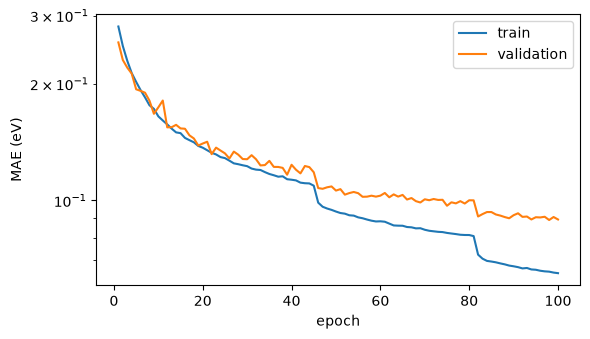

In [28]:
# Plot train and validation error against epoch. Log scale on the y-axis because
# the error spans a wide range and the late improvements matter.

tr = [h[0] for h in history]
va = [h[1] for h in history]

plt.figure(figsize=(6, 3.5))
plt.plot(range(1, len(tr) + 1), tr, label="train")
plt.plot(range(1, len(va) + 1), va, label="validation")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MAE (eV)")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# Loading the best weights and evaluate on the test set. These 10,000 molecules have
# never been used for training or for any decision, making this a more honest number.

model.load_state_dict(best_state)
model.to(device).eval()

preds, truths = [], []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        preds.append((model(data) * y_std + y_mean).cpu())
        truths.append(data.y[:, TARGET].cpu())

preds = torch.cat(preds)
truths = torch.cat(truths)
errors = (preds - truths).abs()

print("test MAE        : %.4f eV" % errors.mean())
print("median error    : %.4f eV" % errors.median())
print("90th percentile : %.4f eV" % errors.quantile(0.90))
print("worst           : %.4f eV" % errors.max())
print()
print("baseline (predict the mean): %.4f eV" % (truths - truths.mean()).abs().mean())

test MAE        : 0.0886 eV
median error    : 0.0617 eV
90th percentile : 0.1965 eV
worst           : 1.6869 eV

baseline (predict the mean): 1.0783 eV


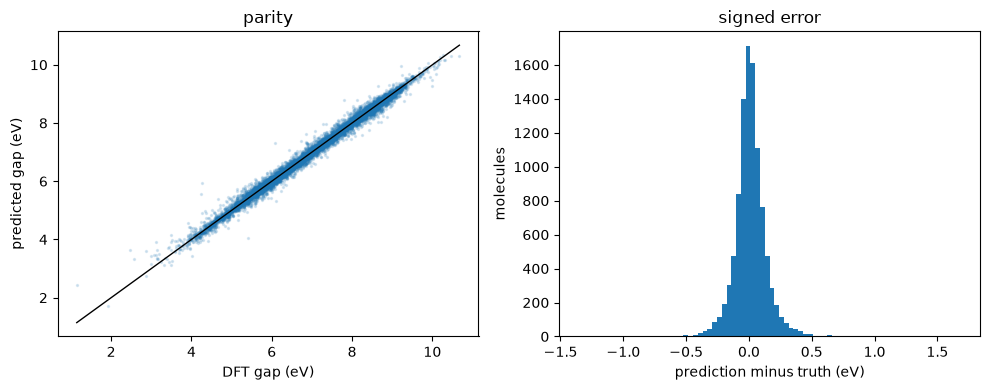

In [30]:
# Two plots. Left: predicted vs true gap, with a diagonal line showing perfect
# prediction. Right: how the errors are distributed, including their sign.

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

lo = float(min(truths.min(), preds.min()))
hi = float(max(truths.max(), preds.max()))
ax[0].scatter(truths.numpy(), preds.numpy(), s=2, alpha=0.15)
ax[0].plot([lo, hi], [lo, hi], linewidth=1, color="black")
ax[0].set_xlabel("DFT gap (eV)")
ax[0].set_ylabel("predicted gap (eV)")
ax[0].set_title("parity")

ax[1].hist((preds - truths).numpy(), bins=80)
ax[1].set_xlabel("prediction minus truth (eV)")
ax[1].set_ylabel("molecules")
ax[1].set_title("signed error")

plt.tight_layout()
plt.show()

In [31]:
# Compute the length of every bond in one molecule from its 3D coordinates.
# Check the values are chemically sensible before building anything on them.
# so pretty much adding a new feature to the model based on the 3D coordinates of the molecule

src, dst = toy.edge_index
d = (toy.pos[src] - toy.pos[dst]).norm(dim=1)

seen = set()
for e in range(toy.edge_index.size(1)):
    i, j = int(src[e]), int(dst[e])
    if (j, i) in seen:
        continue
    seen.add((i, j))
    print("  %s%d -- %s%d   %.3f A" % (symbols[i], i, symbols[j], j, d[e]))

  O0 -- C1   1.404 A
  O0 -- H5   0.962 A
  C1 -- C2   1.515 A
  C1 -- C3   1.502 A
  C1 -- H6   1.088 A
  C2 -- C3   1.516 A
  C2 -- H7   1.085 A
  C2 -- H8   1.086 A
  C3 -- O4   1.391 A
  C3 -- H9   1.086 A
  O4 -- H10   0.968 A


In [32]:
# Build the new model and push one batch through it. Confirms the shapes work
# and shows how many more weights it has than the bond-only version.

probe3d = GapNet3D()
print("GapNet3D parameters:", sum(p.numel() for p in probe3d.parameters()))
print("GapNet   parameters:", sum(p.numel() for p in GapNet().parameters()))

sample_batch = next(iter(DataLoader(dataset[:32], batch_size=32)))
with torch.no_grad():
    out = probe3d(sample_batch)

print()
print("atoms in batch      :", sample_batch.x.shape[0])
print("bonds in batch      :", sample_batch.edge_index.shape[1])
print("predictions returned:", tuple(out.shape))

GapNet3D parameters: 423681
GapNet   parameters: 415489

atoms in batch      : 230
bonds in batch      : 400
predictions returned: (32,)


In [33]:
print("final val MAE in history:", history[-1][1])
print("best val MAE:", best_val)

final val MAE in history: 0.08929474508843507
best val MAE: 0.089020770122727


In [52]:
# The pre-processed QM9 has no SMILES strings, so rebuild the molecule from the
# graph tensors instead: add each atom, then each bond with its order.

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.rdchem import BondType

ATOMIC_NUM = {0: 1, 1: 6, 2: 7, 3: 8, 4: 9}      # H, C, N, O, F
BOND_ORDER = [BondType.SINGLE, BondType.DOUBLE, BondType.TRIPLE, BondType.AROMATIC]


def data_to_rdkit(d):
    m = Chem.RWMol()
    for row in d.x[:, :5]:
        m.AddAtom(Chem.Atom(ATOMIC_NUM[int(row.argmax())]))

    seen = set()
    for e in range(d.edge_index.size(1)):
        i, j = int(d.edge_index[0, e]), int(d.edge_index[1, e])
        if (j, i) in seen or (i, j) in seen:
            continue
        seen.add((i, j))
        m.AddBond(i, j, BOND_ORDER[int(d.edge_attr[e].argmax())])

    return m.GetMol()

In [42]:
# Rebuild an RDKit molecule from the graph tensors. QM9 stores every hydrogen as
# a real atom, so implicit hydrogens are switched off and valences are computed
# explicitly before any 3D work.

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.rdchem import BondType

ATOMIC_NUM = {0: 1, 1: 6, 2: 7, 3: 8, 4: 9}
BOND_ORDER = [BondType.SINGLE, BondType.DOUBLE, BondType.TRIPLE, BondType.AROMATIC]


def data_to_rdkit(d):
    m = Chem.RWMol()
    for row in d.x[:, :5]:
        atom = Chem.Atom(ATOMIC_NUM[int(row.argmax())])
        atom.SetNoImplicit(True)
        atom.SetNumExplicitHs(0)
        m.AddAtom(atom)

    seen = set()
    for e in range(d.edge_index.size(1)):
        i, j = int(d.edge_index[0, e]), int(d.edge_index[1, e])
        if (j, i) in seen or (i, j) in seen:
            continue
        seen.add((i, j))
        m.AddBond(i, j, BOND_ORDER[int(d.edge_attr[e].argmax())])

    mol = m.GetMol()
    try:
        mol.UpdatePropertyCache(strict=False)
        Chem.SanitizeMol(mol)
    except Exception:
        return None
    return mol


# Quick check on one molecule before running the full experiment.
test_mol = data_to_rdkit(test_set[0])
print("built:", test_mol is not None)
if test_mol is not None:
    print("atoms:", test_mol.GetNumAtoms(), "expected:", test_set[0].num_nodes)
    print("embed result:", AllChem.EmbedMolecule(test_mol, randomSeed=0))

built: True
atoms: 17 expected: 17
embed result: 0


In [53]:
# Does the 3D model still work when coordinates come from a force field instead
# of DFT? Rebuilds each molecule from its graph, generates fresh coordinates with
# RDKit, and compares predictions against the original DFT geometry.

import copy

model.load_state_dict(torch.load("best_model_3d.pt", map_location=device))
model.to(device).eval()

n_check = 200
dft_preds, rdkit_preds, actual = [], [], []
skipped = 0

for k in range(n_check):
    d = test_set[k]

    mol = data_to_rdkit(d)
    if mol is None:
        skipped += 1
        continue

    if AllChem.EmbedMolecule(mol, randomSeed=0) != 0:
        skipped += 1
        continue
    AllChem.MMFFOptimizeMolecule(mol)

    if mol.GetNumAtoms() != d.num_nodes:
        skipped += 1
        continue

    conf = mol.GetConformer()
    new_pos = torch.tensor(conf.GetPositions(), dtype=torch.float)

    d_rdkit = copy.copy(d)
    d_rdkit.pos = new_pos

    with torch.no_grad():
        a = model(Batch.from_data_list([d]).to(device)) * y_std + y_mean
        b = model(Batch.from_data_list([d_rdkit]).to(device)) * y_std + y_mean

    dft_preds.append(a.item())
    rdkit_preds.append(b.item())
    actual.append(d.y[0, TARGET].item())

dft_preds = torch.tensor(dft_preds)
rdkit_preds = torch.tensor(rdkit_preds)
actual = torch.tensor(actual)

print("molecules used:", len(actual), " skipped:", skipped)
print()
print("MAE with DFT geometry   : %.4f eV" % (dft_preds - actual).abs().mean())
print("MAE with RDKit geometry : %.4f eV" % (rdkit_preds - actual).abs().mean())
print("mean shift between them : %.4f eV" % (dft_preds - rdkit_preds).abs().mean())

[20:04:19] 

****
Pre-condition Violation
getNumImplicitHs() called without preceding call to calcImplicitValence()
Violation occurred on line 305 in file /Users/runner/work/rdkit-pypi/rdkit-pypi/build/temp.macosx-11.0-arm64-cpython-311/rdkit/Code/GraphMol/Atom.cpp
Failed Expression: d_implicitValence > -1
****



RuntimeError: Pre-condition Violation
	getNumImplicitHs() called without preceding call to calcImplicitValence()
	Violation occurred on line 305 in file Code/GraphMol/Atom.cpp
	Failed Expression: d_implicitValence > -1
	RDKIT: 2026.03.5
	BOOST: 1_85


In [54]:
import inspect
print(inspect.getsource(data_to_rdkit))

def data_to_rdkit(d):
    m = Chem.RWMol()
    for row in d.x[:, :5]:
        m.AddAtom(Chem.Atom(ATOMIC_NUM[int(row.argmax())]))

    seen = set()
    for e in range(d.edge_index.size(1)):
        i, j = int(d.edge_index[0, e]), int(d.edge_index[1, e])
        if (j, i) in seen or (i, j) in seen:
            continue
        seen.add((i, j))
        m.AddBond(i, j, BOND_ORDER[int(d.edge_attr[e].argmax())])

    return m.GetMol()



In [62]:
# Round-trip test: take QM9 molecules, convert to SMILES, convert back through
# the new code, and check the tensors match the originals exactly.

import importlib
import smiles_to_graph
importlib.reload(smiles_to_graph)

matches, mismatches, failed = 0, 0, 0

for k in range(100):
    d = test_set[k]
    mol = data_to_rdkit(d)
    if mol is None:
        failed += 1
        continue

    smiles = Chem.MolToSmiles(Chem.RemoveHs(mol))

    try:
        rebuilt = smiles_to_graph.smiles_to_data(smiles)
    except Exception as e:
        failed += 1
        continue

    if rebuilt.x.shape != d.x.shape:
        mismatches += 1
        continue

    # Atom order may differ, so compare sorted feature rows and bond counts.
    a = torch.sort(d.x, dim=0).values
    b = torch.sort(rebuilt.x, dim=0).values

    if torch.allclose(a, b, atol=1e-4) and rebuilt.edge_index.shape == d.edge_index.shape:
        matches += 1
    else:
        mismatches += 1

print("matched:", matches, " mismatched:", mismatches, " failed:", failed)

matched: 85  mismatched: 15  failed: 0


In [55]:
# Diff one molecule column by column to find which feature is wrong.

d = test_set[0]
mol = data_to_rdkit(d)
smiles = Chem.MolToSmiles(Chem.RemoveHs(mol))
rebuilt = smiles_to_graph.smiles_to_data(smiles)

print("SMILES:", smiles)
print("QM9 shape:", tuple(d.x.shape), "  rebuilt shape:", tuple(rebuilt.x.shape))
print("QM9 edges:", d.edge_index.shape[1], "  rebuilt edges:", rebuilt.edge_index.shape[1])
print()

cols = ["H", "C", "N", "O", "F", "Z", "arom", "sp", "sp2", "sp3", "nH"]

print("QM9 atom features:")
print("      " + "".join(c.rjust(6) for c in cols))
for i, row in enumerate(d.x):
    print(("  %2d  " % i) + "".join(("%.0f" % v).rjust(6) for v in row))

print()
print("rebuilt atom features:")
print("      " + "".join(c.rjust(6) for c in cols))
for i, row in enumerate(rebuilt.x):
    print(("  %2d  " % i) + "".join(("%.0f" % v).rjust(6) for v in row))

SMILES: CC1CC(NCC#N)O1
QM9 shape: (17, 11)   rebuilt shape: (19, 11)
QM9 edges: 34   rebuilt edges: 38

QM9 atom features:
           H     C     N     O     F     Z  arom    sp   sp2   sp3    nH
   0       0     1     0     0     0     6     0     0     0     0     3
   1       0     1     0     0     0     6     0     0     0     0     1
   2       0     1     0     0     0     6     0     0     0     0     2
   3       0     1     0     0     0     6     0     0     0     0     0
   4       0     0     0     1     0     8     0     0     0     0     0
   5       0     0     1     0     0     7     0     0     0     0     0
   6       0     1     0     0     0     6     0     0     0     0     2
   7       0     1     0     0     0     6     0     0     0     0     0
   8       0     0     1     0     0     7     0     0     0     0     0
   9       1     0     0     0     0     1     0     0     0     0     0
  10       1     0     0     0     0     1     0     0     0     0     0
 

In [49]:
# Inspect the mismatched molecules to see what they share.

bad = []
for k in range(100):
    d = test_set[k]
    mol = data_to_rdkit(d)
    if mol is None:
        continue
    smiles = Chem.MolToSmiles(Chem.RemoveHs(mol))
    try:
        rebuilt = smiles_to_graph.smiles_to_data(smiles)
    except Exception:
        continue

    if rebuilt.x.shape != d.x.shape:
        bad.append((k, smiles, "shape", tuple(d.x.shape), tuple(rebuilt.x.shape)))
        continue

    a = torch.sort(d.x, dim=0).values
    b = torch.sort(rebuilt.x, dim=0).values
    if not torch.allclose(a, b, atol=1e-4):
        diff = (a - b).abs().sum(dim=0)
        worst = int(diff.argmax())
        bad.append((k, smiles, "column", worst, float(diff[worst])))
    elif rebuilt.edge_index.shape != d.edge_index.shape:
        bad.append((k, smiles, "edges", d.edge_index.shape[1], rebuilt.edge_index.shape[1]))

cols = ["H", "C", "N", "O", "F", "Z", "arom", "sp", "sp2", "sp3", "nH"]
for entry in bad:
    k, smiles, kind = entry[0], entry[1], entry[2]
    if kind == "column":
        print("%3d  %-30s column %s  total diff %.0f" % (k, smiles, cols[entry[3]], entry[4]))
    else:
        print("%3d  %-30s %s: %s vs %s" % (k, smiles, kind, entry[3], entry[4]))
        

  9  Oc1cc2n(n1)CCO2                column arom  total diff 5
 15  O=Cc1ccco1                     column arom  total diff 5
 19  COc1c[nH]c(N)c1O               column arom  total diff 5
 25  CC1COc2ncnn21                  column arom  total diff 5
 35  CCNc1nc(O)co1                  column arom  total diff 5
 43  COc1nc[nH]c1CO                 column arom  total diff 5
 48  c1cnc2nccn2c1                  column arom  total diff 9
 53  COc1ncoc1OC                    column arom  total diff 5
 64  C#Cc1cnc(F)nn1                 column arom  total diff 6
 68  COc1onnc1N                     column arom  total diff 5
 72  O=c1[nH]c(CO)no1               column arom  total diff 5
 82  CNc1[nH]cnc1O                  column arom  total diff 5
 98  N#Cc1nocc1C=O                  column arom  total diff 5


[19:58:37] Explicit valence for atom # 2 N, 4, is greater than permitted
[19:58:37] Explicit valence for atom # 5 C, 5, is greater than permitted
[19:58:37] Explicit valence for atom # 5 N, 4, is greater than permitted
[19:58:37] Explicit valence for atom # 6 C, 5, is greater than permitted


In [56]:
d = test_set[9]
print("QM9 aromatic flags   :", d.x[:, 6].tolist())

mol = data_to_rdkit(d)
rebuilt = smiles_to_graph.smiles_to_data(Chem.MolToSmiles(Chem.RemoveHs(mol)))
print("rebuilt aromatic flags:", rebuilt.x[:, 6].tolist())

print()
print("QM9 bond types (summed):", d.edge_attr.sum(dim=0).tolist())
print("rebuilt bond types     :", rebuilt.edge_attr.sum(dim=0).tolist())

QM9 aromatic flags   : [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
rebuilt aromatic flags: [0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

QM9 bond types (summed): [28.0, 4.0, 0.0, 0.0]
rebuilt bond types     : [22.0, 0.0, 0.0, 10.0]


In [58]:
import importlib, inspect
importlib.reload(smiles_to_graph)
print(inspect.getsource(smiles_to_graph.parse_smiles))

def parse_smiles(smiles):
    """Parse and validate a SMILES string. Returns an RDKit molecule with
    explicit hydrogens, or raises InvalidMolecule with a readable reason."""

    if not smiles or not smiles.strip():
        raise InvalidMolecule("No molecule entered.")

    mol = Chem.MolFromSmiles(smiles.strip())
    if mol is None:
        raise InvalidMolecule("Could not parse that SMILES string.")

    heavy = mol.GetNumAtoms()
    if heavy > MAX_HEAVY_ATOMS:
        raise InvalidMolecule(
            "This molecule has %d heavy atoms. The model was trained on "
            "molecules with at most %d, so its prediction would be unreliable."
            % (heavy, MAX_HEAVY_ATOMS)
        )

    found = {a.GetSymbol() for a in mol.GetAtoms()}
    outside = found - ALLOWED_ELEMENTS
    if outside:
        raise InvalidMolecule(
            "Contains %s. The model was trained only on H, C, N, O and F."
            % ", ".join(sorted(outside))
        )

    if any(a.GetFormalCharge(

In [59]:
d = test_set[9]
mol = data_to_rdkit(d)
smiles = Chem.MolToSmiles(Chem.RemoveHs(mol))
rebuilt = smiles_to_graph.smiles_to_data(smiles)

print("SMILES:", smiles)
print()
print("QM9 bonds :", d.edge_attr.sum(dim=0).tolist())
print("rebuilt   :", rebuilt.edge_attr.sum(dim=0).tolist())
print("QM9 arom  :", d.x[:, 6].sum().item())
print("rebuilt   :", rebuilt.x[:, 6].sum().item())

SMILES: Oc1cc2n(n1)CCO2

QM9 bonds : [28.0, 4.0, 0.0, 0.0]
rebuilt   : [28.0, 4.0, 0.0, 0.0]
QM9 arom  : 0.0
rebuilt   : 0.0


In [61]:
import importlib
import smiles_to_graph
importlib.reload(smiles_to_graph)

matches, mismatches, failed = 0, 0, 0

for k in range(100):
    d = test_set[k]
    mol = data_to_rdkit(d)
    if mol is None:
        failed += 1
        continue

    smiles = Chem.MolToSmiles(Chem.RemoveHs(mol))

    try:
        rebuilt = smiles_to_graph.smiles_to_data(smiles)
    except Exception:
        failed += 1
        continue

    if rebuilt.x.shape != d.x.shape:
        mismatches += 1
        continue

    a = torch.sort(d.x, dim=0).values
    b = torch.sort(rebuilt.x, dim=0).values

    if torch.allclose(a, b, atol=1e-4) and rebuilt.edge_index.shape == d.edge_index.shape:
        matches += 1
    else:
        mismatches += 1

print("matched:", matches, " mismatched:", mismatches, " failed:", failed)

matched: 85  mismatched: 15  failed: 0


In [63]:
importlib.reload(smiles_to_graph)

cols = ["H", "C", "N", "O", "F", "Z", "arom", "sp", "sp2", "sp3", "nH"]

for k in range(100):
    d = test_set[k]
    mol = data_to_rdkit(d)
    if mol is None:
        continue
    smiles = Chem.MolToSmiles(Chem.RemoveHs(mol))
    try:
        rebuilt = smiles_to_graph.smiles_to_data(smiles)
    except Exception:
        continue

    if rebuilt.x.shape != d.x.shape:
        print("%3d  %-28s shape %s vs %s"
              % (k, smiles, tuple(d.x.shape), tuple(rebuilt.x.shape)))
        continue

    a = torch.sort(d.x, dim=0).values
    b = torch.sort(rebuilt.x, dim=0).values

    if not torch.allclose(a, b, atol=1e-4):
        diff = (a - b).abs().sum(dim=0)
        worst = int(diff.argmax())
        print("%3d  %-28s column %-5s diff %.0f"
              % (k, smiles, cols[worst], diff[worst]))
    elif rebuilt.edge_index.shape != d.edge_index.shape:
        print("%3d  %-28s edges %d vs %d"
              % (k, smiles, d.edge_index.shape[1], rebuilt.edge_index.shape[1]))

  0  CC1CC(NCC#N)O1               shape (17, 11) vs (19, 11)
  4  NC1OC2COC1OC2                shape (16, 11) vs (18, 11)
 16  NC1OC2CCC1NC2                shape (19, 11) vs (21, 11)
 23  CC1C=CNC(N)C1=O              shape (17, 11) vs (19, 11)
 30  Nc1cc(C=O)nnn1               column nH    diff 2
 31  N#CC1(N)C2C34OC23C14         shape (15, 11) vs (13, 11)
 42  CC1(C=O)OCC(N)O1             shape (16, 11) vs (18, 11)
 44  CC1OCC12COCN2                shape (18, 11) vs (20, 11)
 49  CNCC(=O)OCN                  shape (16, 11) vs (18, 11)
 51  Nc1cc(O)nc(O)n1              column nH    diff 2
 55  CC1N2C(N)CC12C#N             shape (16, 11) vs (18, 11)
 56  COC(C)CC(N)OC                shape (22, 11) vs (24, 11)
 59  OC12CC=CC3C14OC324           shape (17, 11) vs (15, 11)
 60  OCCNCOC1CC1                  shape (20, 11) vs (22, 11)
 66  ONC1CC(O)C12CO2              shape (16, 11) vs (18, 11)
